# Titanic EDA

Коротко: смотрим структуру Titanic, пропуски, таргет и первые сигналы для будущих признаков.


## Setup / Настройка


In [1]:
# База / core
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml

# Стиль / style
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 70)
plt.rcParams["figure.figsize"] = (8, 4)


In [2]:
# Данные как в задании / data as in the task
# fetch_openml("titanic", version=1, as_frame=True).frame
df = fetch_openml("titanic", version=1, as_frame=True).frame
y = df["survived"].astype(int)  # таргет / target

print(f"shape: {df.shape}")
df.head()


shape: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## Overview / Обзор


In [3]:
# Структура / structure
display(df.info())
display(df.describe(include="all").T)


<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   str     
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   str     
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    str     
 10  embarked   1307 non-null   category
 11  boat       486 non-null    str     
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    str     
dtypes: category(3), float64(3), int64(3), str(5)
memory usage: 176.1 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pclass,1309.0,NaN,NaN,NaN,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0
survived,1309,2,0,809,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,1309,1307,"Connolly, Miss. Kate",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,1309,2,male,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1046.0,NaN,NaN,NaN,29.881135,14.4135,0.1667,21.0,28.0,39.0,80.0
sibsp,1309.0,NaN,NaN,NaN,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0
parch,1309.0,NaN,NaN,NaN,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0
ticket,1309,929,CA. 2343,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare,1308.0,NaN,NaN,NaN,33.295479,51.758668,0.0,7.8958,14.4542,31.275,512.3292
cabin,295,186,C23 C25 C27,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Пропуски и таргет / missing & target
missing = df.isna().mean().mul(100).round(1).sort_values(ascending=False)

display(missing.to_frame("missing_%"))
display(y.value_counts(normalize=True).rename("share").round(3).to_frame())
print(f"majority baseline: {(y == y.mode()[0]).mean():.3f}")


,missing_%
body,90.8
cabin,77.5
boat,62.9
home.dest,43.1
age,20.1
embarked,0.2
fare,0.1
sibsp,0.0
name,0.0
survived,0.0


,share
survived,
0,0.618
1,0.382


majority baseline: 0.618


## Helpers / Мини-функции


In [5]:
# Маленькие обертки / tiny wrappers
def show(title: str, xlabel: str | None = None, ylabel: str | None = None):
    plt.title(title)
    plt.xlabel(xlabel or "")
    plt.ylabel(ylabel or "")
    plt.tight_layout()
    plt.show()


def count_plot(x: str, title: str, data=df, hue="survived"):
    sns.countplot(data=data, x=x, hue=hue)
    show(title)


def hist_plot(x: str, title: str, bins=30):
    sns.histplot(data=df, x=x, bins=bins, kde=True)
    show(title)


def box_plot(y_col: str, title: str, ylim=None):
    sns.boxplot(data=df, x="survived", y=y_col)
    if ylim:
        plt.ylim(*ylim)
    show(title, xlabel="survived", ylabel=y_col)


## Missing / Пропуски


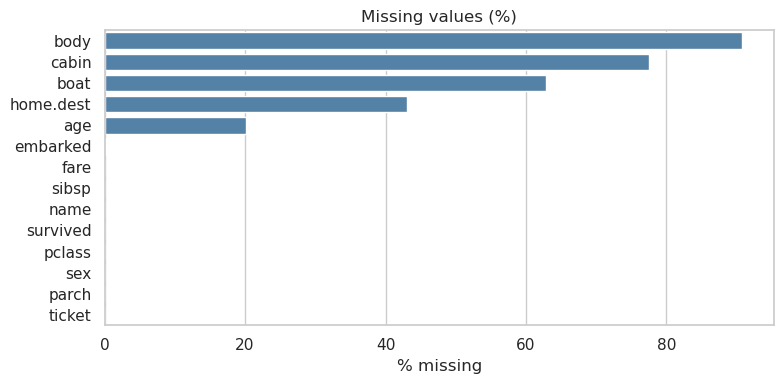

In [6]:
# Пропуски / missing
sns.barplot(x=missing.values, y=missing.index, color="steelblue")
show("Missing values (%)", xlabel="% missing")


## Target / Целевая переменная


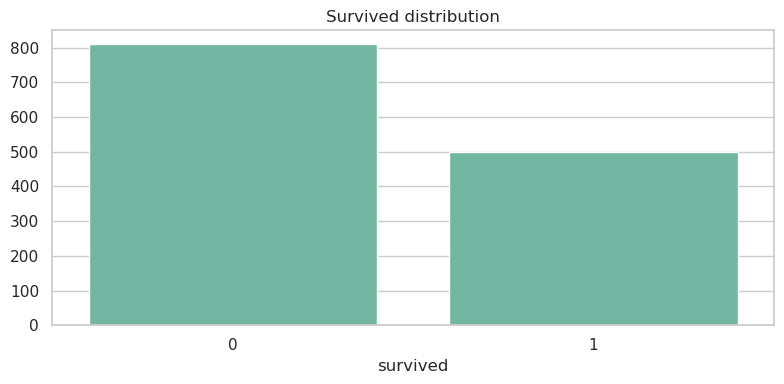

In [7]:
# Баланс классов / class balance
sns.countplot(data=df, x="survived")
show("Survived distribution", xlabel="survived")


## Numeric Features / Числовые признаки


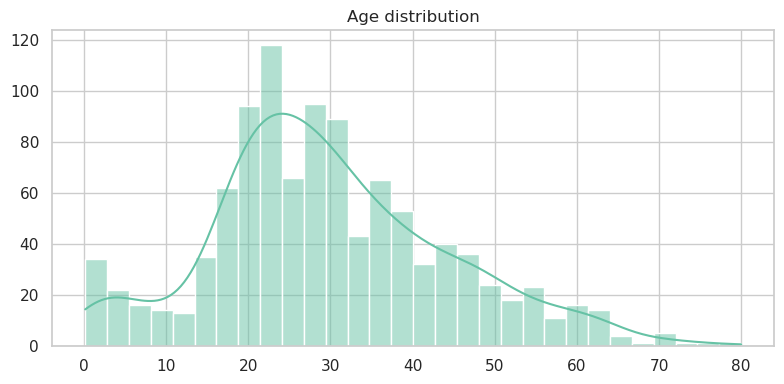

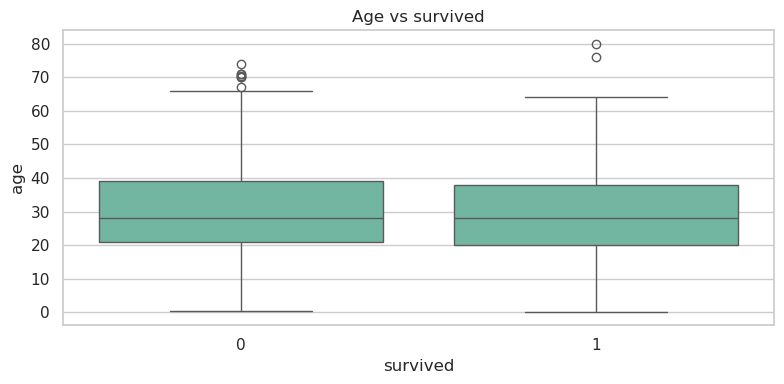

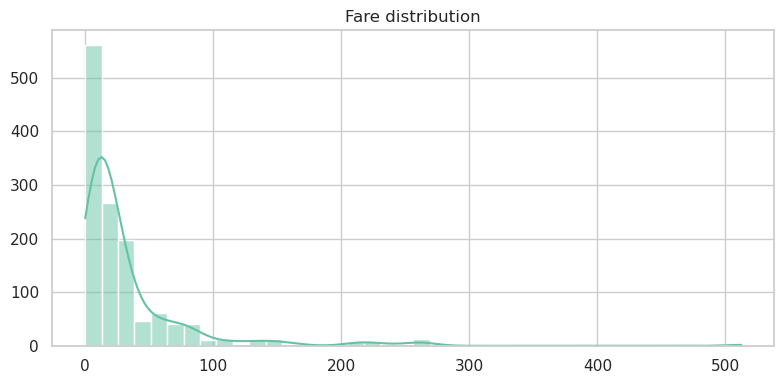

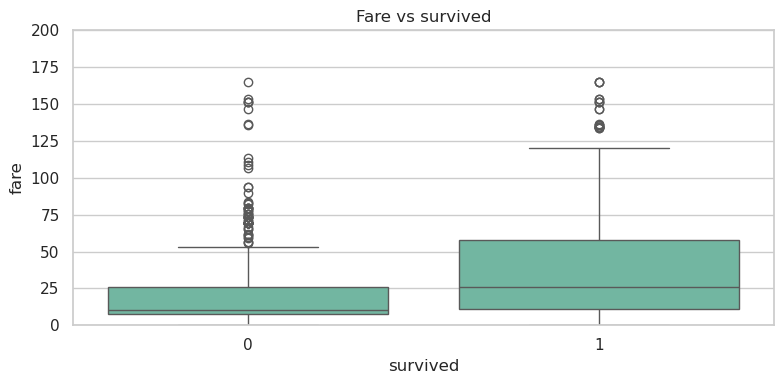

In [8]:
# Возраст и цена / age & fare
hist_plot("age", "Age distribution")
box_plot("age", "Age vs survived")

hist_plot("fare", "Fare distribution", bins=40)
box_plot("fare", "Fare vs survived", ylim=(0, 200))


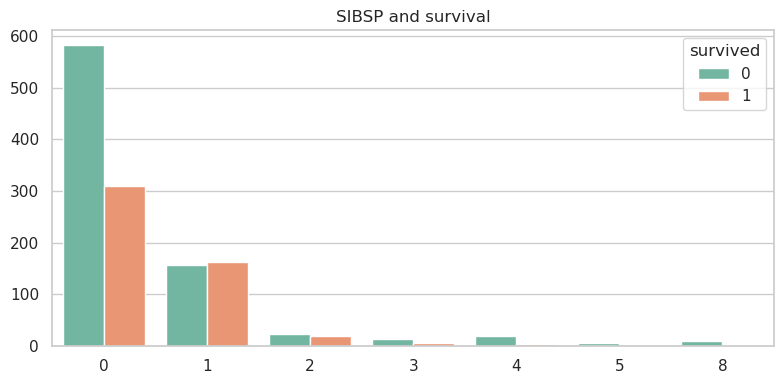

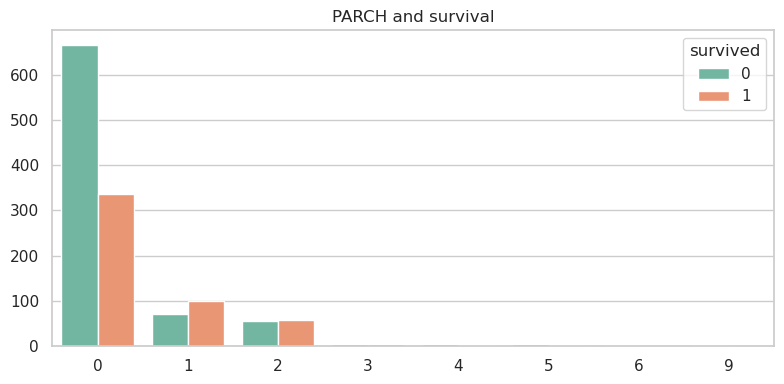

In [9]:
# Семья / family
for col in ["sibsp", "parch"]:
    count_plot(col, f"{col.upper()} and survival")


## Categorical Features / Категории


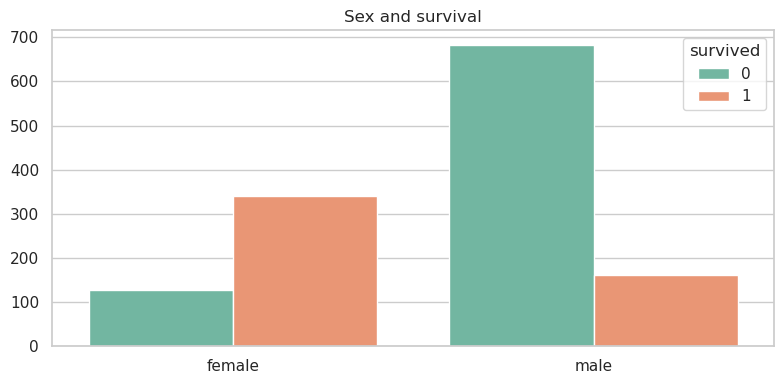

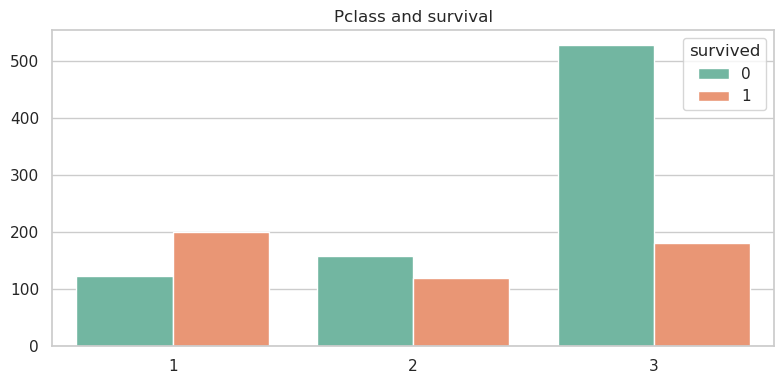

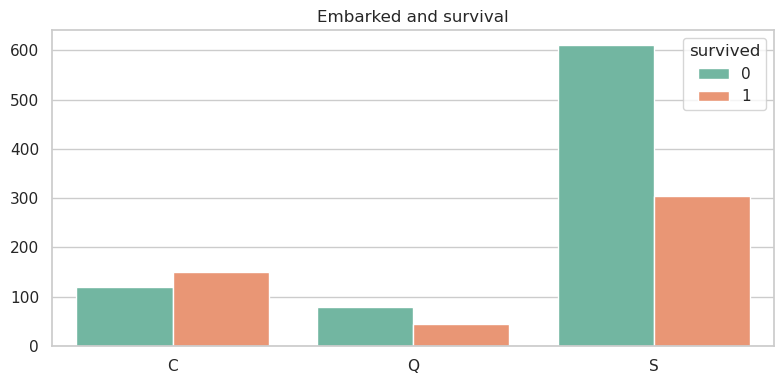

In [10]:
# Пол, класс, порт / sex, class, embarked
for col in ["sex", "pclass", "embarked"]:
    count_plot(col, f"{col.capitalize()} and survival")


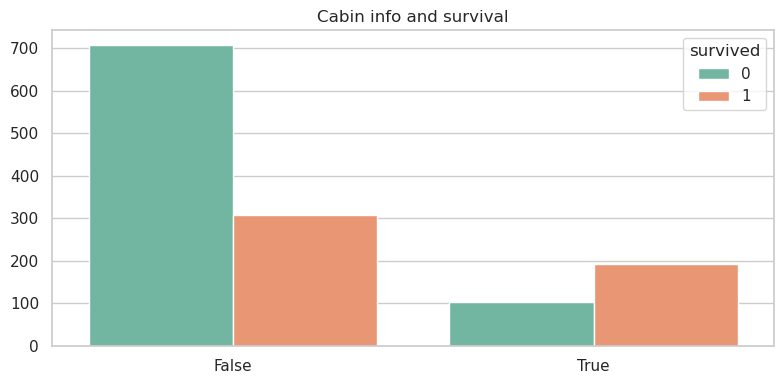

In [11]:
# Каюта как сигнал / cabin as signal
cabin_df = df.assign(HasCabin=df["cabin"].notna())
count_plot("HasCabin", "Cabin info and survival", data=cabin_df)


## Interactions / Взаимодействия


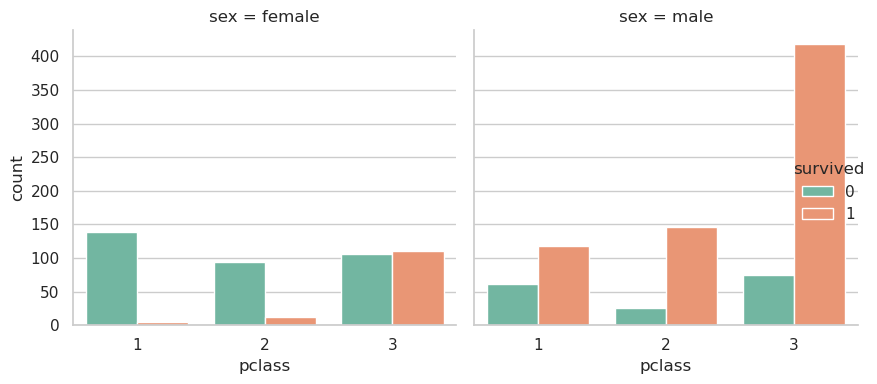

In [12]:
# Пол x класс / sex x class
sns.catplot(data=df, x="pclass", hue="survived", col="sex", kind="count", height=4, aspect=1)
plt.tight_layout()
plt.show()


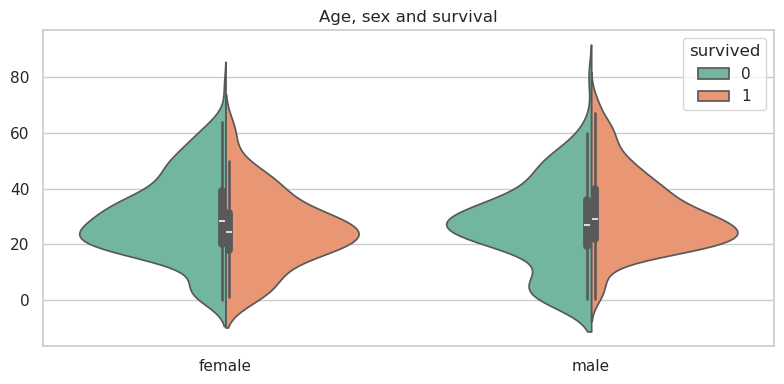

In [13]:
# Возраст x пол / age x sex
sns.violinplot(data=df, x="sex", y="age", hue="survived", split=True)
show("Age, sex and survival")


## Quick Checks / Быстрые проверки


In [14]:
# Имена и билеты / names & tickets
display(df["name"].sample(10, random_state=42).to_frame())
display(df["ticket"].value_counts().head(15).to_frame("count"))


,name
1148,"Rintamaki, Mr. Matti"
1049,"Nakid, Mr. Sahid"
982,"Lyntakoff, Mr. Stanko"
808,"Ford, Mr. Arthur"
1195,"Shaughnessy, Mr. Patrick"
240,"Romaine, Mr. Charles Hallace ('Mr C Rolmane')"
1118,"Peltomaki, Mr. Nikolai Johannes"
596,"Wilhelms, Mr. Charles"
924,"Kelly, Mr. James"
65,"Chambers, Mrs. Norman Campbell (Bertha Griggs)"


,count
ticket,
CA. 2343,11
1601,8
CA 2144,8
PC 17608,7
S.O.C. 14879,7
347082,7
347077,7
3101295,7
113781,6


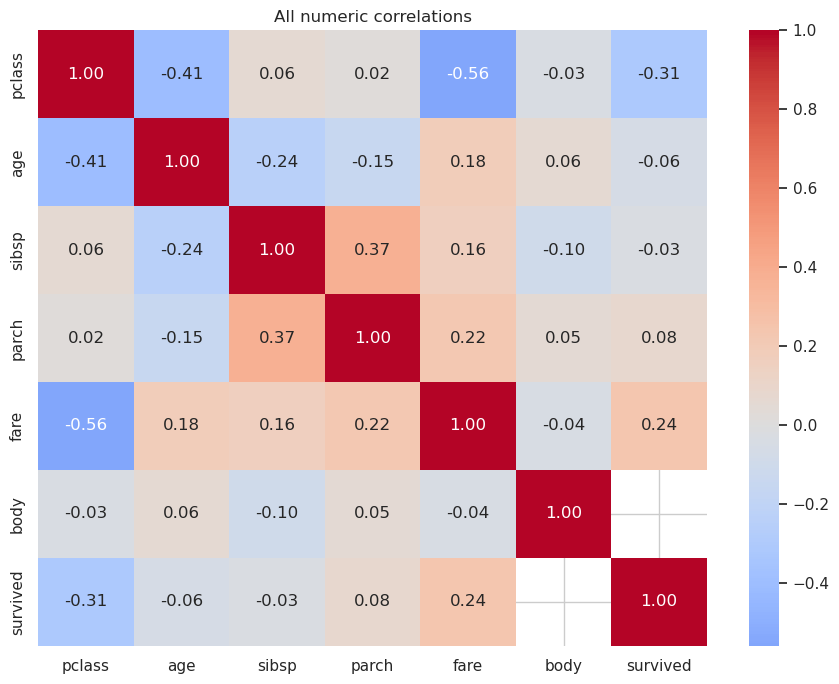

In [15]:
# Корреляции по всем числовым / all numeric correlations
corr_df = df.select_dtypes(include="number").assign(survived=y)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
show("All numeric correlations")


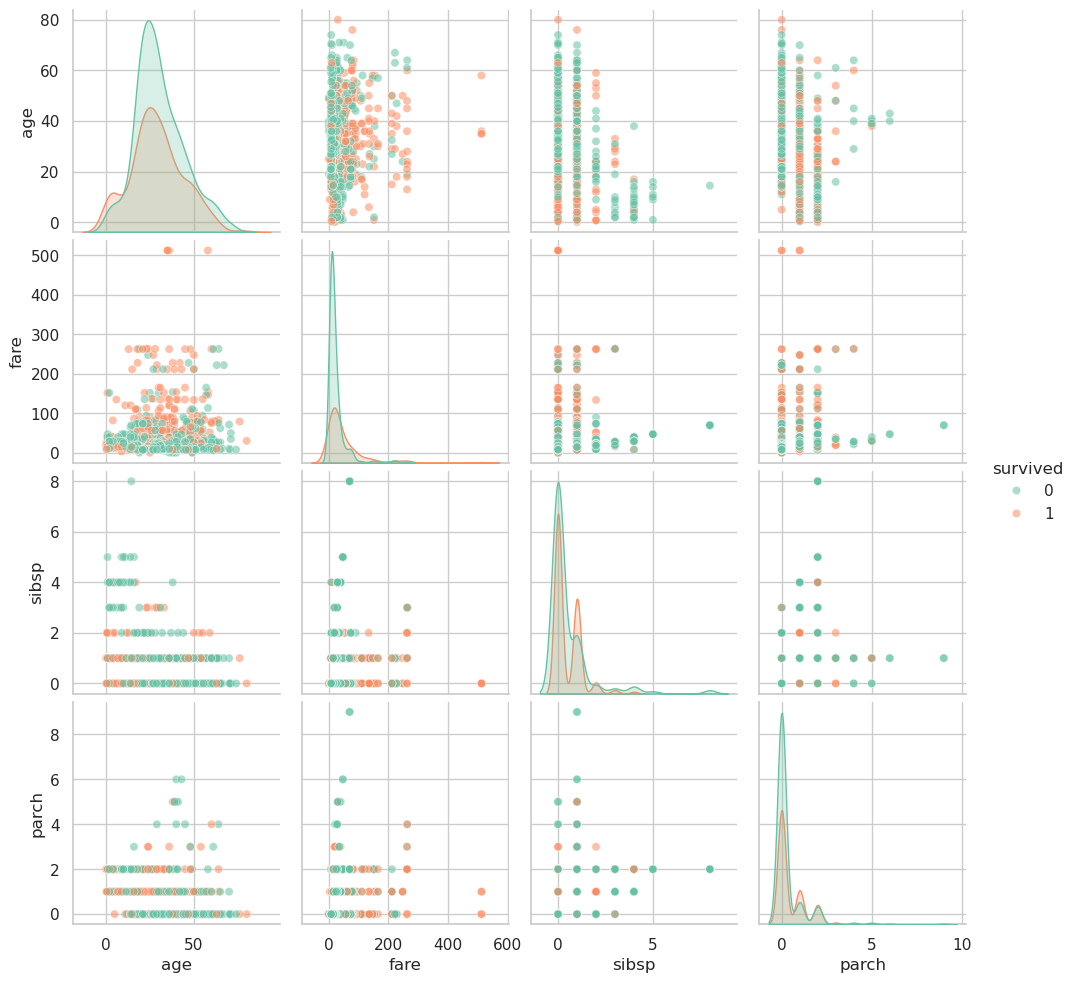

In [16]:
# Pairplot: полная сетка / full grid
pair_cols = ["age", "fare", "sibsp", "parch", "survived"]
sns.pairplot(df[pair_cols], hue="survived", corner=False, plot_kws={"alpha": 0.55})
plt.show()


## EDA Summary / Итоги

- `sex` и `pclass` дают самый заметный визуальный сигнал.
- `age`, `fare`, `sibsp`, `parch` полезны, но требуют аккуратного препроцессинга.
- `cabin` сильно пропущен, но сам факт наличия каюты выглядит информативным.
- `name` и `ticket` можно превратить в признаки: титул, размер группы, приставка билета.
- Колонки `boat`, `body`, `home.dest` нельзя использовать в честной модели: это post-event leakage.


## Входы, выходы и выводы / Inputs, outputs & conclusions

- Вход: датасет Titanic из OpenML.
- Выход: список заметных сигналов и рисков для модели.
- Вывод: `sex`, `pclass`, возраст, цена и семейные признаки выглядят полезно; `cabin` лучше превращать в индикатор наличия каюты; `boat`, `body`, `home.dest` нельзя использовать как честные признаки из-за утечки.
